In [1]:
# Test script 1

In [8]:
import xarray as xr
import os
import numpy as np
import pandas as pd

In [9]:
DIR = "/glade/work/awells/air_quality/GBD19_burdendata/"

In [24]:
import os
import pandas as pd
import xarray as xr

# === Setup ===
DIR = "/glade/work/awells/air_quality/GBD19_burdendata/"
SAVE_DIR = "/glade/work/awells/air_quality/GBD19_burdendata/RR_PM25/"
lookup_base = "MRBRT"
health_vars = ["DM", "LC", "Stroke", "COPD", "LRI", "IHD", "PTB", "LBW"]

# === Load PM2.5 values (assume 1 column with ug/m3) ===
pm25_path = os.path.join(DIR, f"{lookup_base}_PM25.csv")
pm_df = pd.read_csv(pm25_path)
pm25_values = pm_df.iloc[:, 0].values  # 1D array

# === Loop through variables ===
for var in health_vars:
    var_path = os.path.join(DIR, f"{lookup_base}_{var}.csv")
    
    if not os.path.exists(var_path):
        print(f"Warning: {var_path} not found, skipping.")
        continue

    # Load the variable data
    df = pd.read_csv(var_path)

    # Create a DataArray
    da = xr.DataArray(
        data=df.values,
        dims=["pm25", "column"],
        coords={"pm25": pm25_values[:len(df)], "column": df.columns.astype(str)},
        name=var,
        attrs={"description": f"Relative risks for {var} paired with PM2.5 exposure"}
    )

    # Save to NetCDF
    out_path = os.path.join(SAVE_DIR, f"{lookup_base}_{var}.nc")
    da.to_netcdf(out_path)
    print(f"Saved {out_path}")


Saved /glade/work/awells/air_quality/GBD19_burdendata/RR_PM25/MRBRT_DM.nc
Saved /glade/work/awells/air_quality/GBD19_burdendata/RR_PM25/MRBRT_LC.nc
Saved /glade/work/awells/air_quality/GBD19_burdendata/RR_PM25/MRBRT_Stroke.nc
Saved /glade/work/awells/air_quality/GBD19_burdendata/RR_PM25/MRBRT_COPD.nc
Saved /glade/work/awells/air_quality/GBD19_burdendata/RR_PM25/MRBRT_LRI.nc
Saved /glade/work/awells/air_quality/GBD19_burdendata/RR_PM25/MRBRT_IHD.nc
Saved /glade/work/awells/air_quality/GBD19_burdendata/RR_PM25/MRBRT_PTB.nc
Saved /glade/work/awells/air_quality/GBD19_burdendata/RR_PM25/MRBRT_LBW.nc


In [38]:
da = xr.open_dataarray(f"{SAVE_DIR}MRBRT_COPD.nc")

In [12]:
pm = pd.read_csv(f"{DIR}MRBRT_PM25.csv")

In [17]:
# Flatten PM2.5 to 1D array
pm_values = pm.iloc[:, 0].values  # gets the first column as a 1D array

# Create xarray dataset
ds = xr.Dataset(
    {
        "COPD": (["entry", "column"], df.values),
        "PM25_ugm3": ("entry", pm_values)
    },
    coords={
        "entry": range(len(df)),
        "column": df.columns.astype(str)
    },
    attrs={
        "description": "Relative risks for COPD paired with PM2.5 exposure"
    }
)

In [19]:
da = xr.DataArray(
    data=df.values,
    dims=["pm25", "column"],
    coords={"pm25": pm_values, "column": df.columns.astype(str)},
    name="COPD",
    attrs={"description": "Relative risks for COPD paired with PM2.5 exposure"}
)

In [39]:
da

<xarray.DataArray 'COPD' (pm25: 3301, column: 3)> Size: 79kB
[9903 values with dtype=float64]
Coordinates:
  * pm25     (pm25) float64 26kB 0.0 0.1 0.2 0.3 0.4 ... 597.0 598.0 599.0 600.0
  * column   (column) <U10 120B 'COPD' '95% UI' 'Unnamed: 2'
Attributes:
    description:  Relative risks for COPD paired with PM2.5 exposure

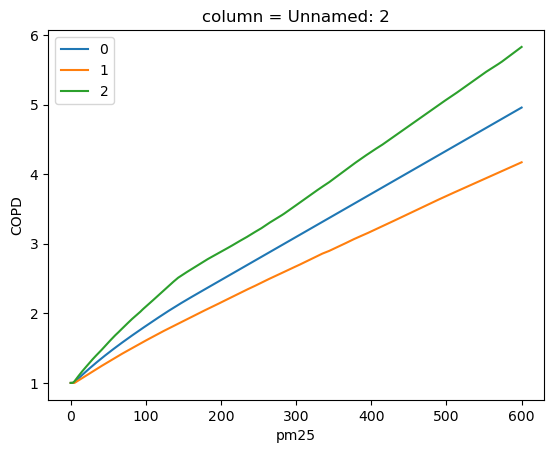

In [40]:
import matplotlib.pyplot as plt
for i in range(3):
    da.isel(column=i).plot(label=i)
    plt.legend()

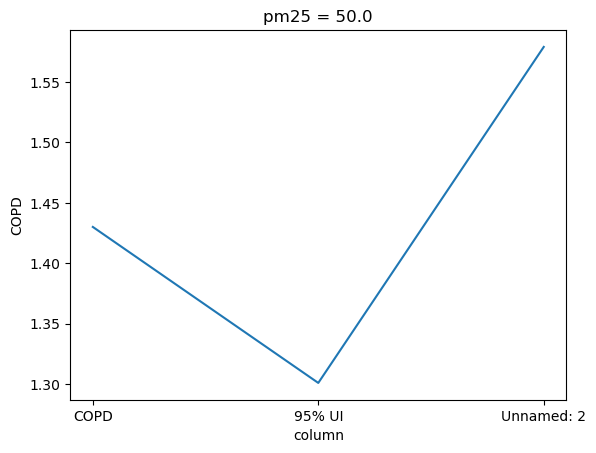

In [45]:
da.sel(pm25=50).plot()